# Matching

The purpose of this file is to do one set of matching: **treatment matching**, to match those who graduated from the program against those that did not graduate from the program. 

We will match to examine the following:

-Graduation effect for **earnings** (income)

-Graduation effect for **employment**

-Graduation effect for **criminal justice interaction** (as measured by arrests)

-Graduation effect for **recidivism** (as measured by offenses)

This will be followed (in future analysis) by intent to treat matching of TIP participants with similar non-participants, which we expect will be particularly relevant for criminal justice and recidivism outcomes. 


# Preparation

In [39]:
#Import necessary packages

import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import tqdm
##!pip install linearmodels
from linearmodels import PanelOLS
import statsmodels.api as sm
from statsmodels.genmod.generalized_estimating_equations import GEE
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.cov_struct import Exchangeable

In [40]:
#Import necessary files

#Student datafile, data up to December 2025 
tip_clean = pd.read_csv(r'TIP_clean.csv', parse_dates=['CreatedDate','DoB', 'Interviewed Only Date', 'InterviewedDate','StartDate','EndDate'])

#Demographic datafile, data up to December 2024
tip_demos = pd.read_csv(r'tip_cohort_demographics_rg.csv')

#Sentencing datafile, data up to December 2024
tip_sentencing = pd.read_csv(r'convictions_matched_to_tip_final.csv', parse_dates = ['DOB', 'GraduatedDate', 'InterviewedDate', 'StartDate','EndDate', 'DOF', 'DOS'])

#Arrests datafile, data up to December 2024
tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])

#Earnings datafile, data up to December 2024
tip_earnings = pd.read_csv(r'tip_cohort_uiearnings.csv')

#Deflation information to deflate earnings data
df_inflation = pd.read_csv(r'inflation_data.csv')

#DHS datafile for non-participants
df_dhs = pd.read_csv(r'DHS_demographics.csv')

#full_pcs data
full_pcs = pd.read_csv(r'full_pcs.txt')

#full_earnings data
full_earnings = pd.read_csv(r'ui_earnings.txt')

C:\Users\13429\AppData\Local\Temp\ipykernel_16440\2219236522.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'CreatedDate','StartDate','EndDate'])
C:\Users\13429\AppData\Local\Temp\ipykernel_16440\2219236522.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  tip_arrests = pd.read_csv(r'arrest_data.csv', parse_dates = ['CaseFiledDate', 'ArrestDate', 'DefendantDOB', 'OffenseDate','OffenseDispositionDate','CaseDispositionDate','InterviewedDate','Orientation Date', 'GraduatedDate', 'Creat

In [41]:
#Clean student datafile column names

all_tip_students = tip_clean.rename(columns={
    'participant_id' : 'tip_id',
    'DoB' : 'DOB',
    'Status' : 'tip_status',
})

all_tip_students.drop(columns=['Unnamed: 25', 'Unnamed: 26'], inplace=True)

#Define statuses as "Graduated" or "Non Graduated" - for the purposes of this matched analysis, we do not care about individuals who do not fall into these statuses

def status(row):
    ts = str(row['tip_status'])
    if ("Graduate" in ts) or ("DNF" in ts and "Orientation" not in ts):
        return 'Participant'
    else:
        return 'Non Participant'

all_tip_students['Status'] = all_tip_students.apply(status, axis=1)
all_tip_students.Status.value_counts()

Status
Participant        1442
Non Participant    1281
Name: count, dtype: int64

In [42]:
# Clean tip_sentencing datafile column names and status
tip_sentencing = tip_sentencing.rename(columns={
    'PCS_OFF_ID': 'pcs_off_id',
    'Status': 'tip_status'
})
tip_sentencing['Status'] = tip_sentencing.apply(status, axis=1)

In [43]:
# -----------------------------
# 1. Create df_participant
# -----------------------------
df_participant = all_tip_students[all_tip_students["Status"] == "Participant"].copy()

# Optional: if you also want the non-participant students from all_tip_students itself
df_non_participant_students = all_tip_students[all_tip_students["Status"] == "Non Participant"].copy()


# -----------------------------
# 2. Check unique non-null pcs_off_id in tip_sentencing
# -----------------------------
tip_pcs_ids = tip_sentencing["pcs_off_id"].dropna().unique()

print("Number of unique non-null pcs_off_id in tip_sentencing:", len(tip_pcs_ids))


# -----------------------------
# 3. Check whether these pcs_off_id have corresponding tip_id
#    (row-level check within tip_sentencing)
# -----------------------------
pcs_tip_check = (
    tip_sentencing.loc[tip_sentencing["pcs_off_id"].notna(), ["pcs_off_id", "tip_id"]]
    .drop_duplicates()
)

# pcs_off_id with at least one non-null tip_id
pcs_with_tip_id = pcs_tip_check.loc[pcs_tip_check["tip_id"].notna(), "pcs_off_id"].unique()

# pcs_off_id that appear but do NOT have any valid tip_id
pcs_without_tip_id = set(tip_pcs_ids) - set(pcs_with_tip_id)

print("Number of unique pcs_off_id with at least one corresponding non-null tip_id:", len(pcs_with_tip_id))
print("Number of unique pcs_off_id without a corresponding non-null tip_id:", len(pcs_without_tip_id))

if len(pcs_without_tip_id) > 0:
    print("pcs_off_id without corresponding tip_id:")
    print(pcs_without_tip_id)
else:
    print("All unique non-null pcs_off_id in tip_sentencing have at least one corresponding non-null tip_id.")


# -----------------------------
# 4. Remove from df_dhs all pcs_off_id that appear in tip_sentencing
#    and create df_non_participant, keep only unique pcs_off_id in df_non_participant
# -----------------------------
df_non_participant = df_dhs[~df_dhs["pcs_off_id"].isin(tip_pcs_ids)].copy()
df_non_participant.drop_duplicates(subset=["pcs_off_id"], inplace=True)

print("Original df_dhs shape:", df_dhs.shape)
print("df_non_participant shape:", df_non_participant.shape)

Number of unique non-null pcs_off_id in tip_sentencing: 1480
Number of unique pcs_off_id with at least one corresponding non-null tip_id: 1480
Number of unique pcs_off_id without a corresponding non-null tip_id: 0
All unique non-null pcs_off_id in tip_sentencing have at least one corresponding non-null tip_id.
Original df_dhs shape: (126232, 6)
df_non_participant shape: (123434, 6)


In [44]:
date_cols = ['DOB', 'StartDate', 'EndDate', 'InterviewedDate', 'Interviewed Only Date']
for col in date_cols:
    if col in df_participant.columns:
        df_participant[col] = pd.to_datetime(df_participant[col], errors = 'coerce')

##Add an indicator for cohort based on StartDate
cutoff = pd.Timestamp("2022-01-01")
df_participant["cohort_2022"] = np.where(
    df_participant["StartDate"].notna(),
    np.where(df_participant["StartDate"] >= cutoff, 1, 0),
    np.nan
)

df_participant["cohort_2022"] = pd.to_numeric(df_participant["cohort_2022"], errors = "coerce")

#Drop anyone with nonsensical ages (under 16)
df_participant = df_participant[df_participant['Age_at_start'] >= 16]

#Add age band based on age at start

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return '<=24'
    elif 25 <= age <= 34:
        return '25-34'
    elif age >= 35:
        return '35+'
    else:
        return np.nan

df_participant['age_band'] = df_participant['Age_at_start'].apply(assign_age_band)

df_participant.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,EndInternet,AccessResume,EndResume,License To Thrive,Workforce Housing,SNAP Assistance,Age_at_start,Status,cohort_2022,age_band
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,25.840055,Participant,0.0,25-34
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,NaN,NaN,NaN,NaN,NaN,NaN,21.424470,Participant,0.0,<=24
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,19.193438,Participant,0.0,<=24
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,30.950103,Participant,0.0,25-34
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,22.605605,Participant,0.0,<=24


In [45]:
#Merge with demographics

tip_demos['tip_id'] = pd.to_numeric(tip_demos['tip_id'], errors='coerce')
df_participant['tip_id'] = pd.to_numeric(df_participant['tip_id'], errors='coerce')

df_participant = df_participant.merge(
    tip_demos,
    on = 'tip_id',
    how = 'left'
)

In [46]:
#Prepare sentencing data

tip_sentencing['DOB'] = pd.to_datetime(tip_sentencing['DOB'], errors='coerce').dt.tz_localize(None)
tip_sentencing['StartDate'] = pd.to_datetime(tip_sentencing['StartDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['EndDate'] = pd.to_datetime(tip_sentencing['EndDate'], errors='coerce').dt.tz_localize(None)
tip_sentencing['tip_id'] = pd.to_numeric(tip_sentencing['tip_id'], errors='coerce')
tip_sentencing['age_at_sentencing'] = (
    (tip_sentencing['DOS'] - tip_sentencing['DOB'])).dt.days // 365

# merge student StartDate for consistent baseline cutoff
tip_sentencing = tip_sentencing.merge(
    df_participant[['tip_id', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_sentencing.columns:
    tip_sentencing['StartDate'] = tip_sentencing['StartDate_student'].combine_first(tip_sentencing['StartDate'])
    tip_sentencing = tip_sentencing.drop(columns=['StartDate_student'])

# before TIP start
sent_before = tip_sentencing[
    tip_sentencing['DOS'].notna() &
    tip_sentencing['StartDate'].notna() &
    (tip_sentencing['DOS'] < tip_sentencing['StartDate'])
].copy()

sent_summary = sent_before.groupby('tip_id').agg(
    num_sentences_before_start=('DOS', 'count'),
    any_sentence_before_start=('DOS', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_sentencing_before_start=('age_at_sentencing', 'min'),
    max_ogs_before_start=('OGS', 'max'),
    any_high_ogs_before_start=('OGS', lambda x: 1 if (x > 5).any() else 0)
).reset_index()

#create wide table
sent_wide= tip_sentencing[['tip_id', 'age_at_sentencing']].drop_duplicates()
sent_wide['value'] = 1
sent_wide = sent_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
sent_wide = sent_wide.reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in sent_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_sentencing_age'
    sent_wide[new_col] = sent_wide[column]
    drop_cols.append(column)

sent_wide = sent_wide.drop(columns=drop_cols)

#create a high OGS table
high_tip_ogs = tip_sentencing[tip_sentencing['OGS'] > 5]
high_tip_ogs_wide = high_tip_ogs[['tip_id', 'age_at_sentencing']].drop_duplicates().dropna()
high_tip_ogs_wide['value'] = 1
high_tip_ogs_wide = high_tip_ogs_wide.pivot(index='tip_id', columns='age_at_sentencing', values='value').fillna(0)
high_tip_ogs_wide = high_tip_ogs_wide.reset_index().rename_axis(None, axis=1)

drop_cols = []
for column in high_tip_ogs_wide.columns[1:]:
    column = int(column)
    new_col = f'{column}_sentencing_age_high_ogs'
    high_tip_ogs_wide[new_col] = high_tip_ogs_wide[column]
    drop_cols.append(column)

high_tip_ogs_wide = high_tip_ogs_wide.drop(columns=drop_cols)

#Merge both wide tables together
sent_wide = sent_wide.merge(
    high_tip_ogs_wide, 
    on='tip_id', 
    how='left').fillna(0)

sent_wide.head()

,tip_id,16_sentencing_age,17_sentencing_age,18_sentencing_age,19_sentencing_age,20_sentencing_age,21_sentencing_age,22_sentencing_age,23_sentencing_age,24_sentencing_age,...,43_sentencing_age_high_ogs,44_sentencing_age_high_ogs,45_sentencing_age_high_ogs,46_sentencing_age_high_ogs,47_sentencing_age_high_ogs,48_sentencing_age_high_ogs,49_sentencing_age_high_ogs,51_sentencing_age_high_ogs,52_sentencing_age_high_ogs,58_sentencing_age_high_ogs
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [47]:
#Prepare arrests data (similar process to conviction data above)

tip_arrests['tip_id'] = pd.to_numeric(tip_arrests['tip_id'], errors='coerce')

tip_arrests = tip_arrests.merge(
    df_participant[['tip_id', 'DOB', 'StartDate']],
    on='tip_id',
    how='left',
    suffixes=('', '_student')
)

if 'StartDate_student' in tip_arrests.columns:
    tip_arrests['StartDate'] = tip_arrests['StartDate_student'].combine_first(tip_arrests['StartDate'])
    tip_arrests = tip_arrests.drop(columns=['StartDate_student'])

tip_arrests['age_at_arrest'] = (
    (tip_arrests['ArrestDate'] - tip_arrests['DOB']).dt.days // 365
)

arrests_before = tip_arrests[
    tip_arrests['ArrestDate'].notna() &
    tip_arrests['StartDate'].notna() &
    (tip_arrests['ArrestDate'] < tip_arrests['StartDate'])
].copy()

arrest_summary = arrests_before.groupby('tip_id').agg(
    num_arrests_before_start=('ArrestDate', 'count'),
    any_arrest_before_start=('ArrestDate', lambda x: 1 if len(x) > 0 else 0),
    min_age_at_arrest_before_start=('age_at_arrest', 'min')
).reset_index()

#pivot wider
arrests_wide = tip_arrests[['tip_id', 'age_at_arrest']].drop_duplicates()
arrests_wide['value'] = 1
arrests_wide = arrests_wide.pivot(index='tip_id', columns='age_at_arrest', values='value').fillna(0).reset_index().rename_axis(None, axis=1)

drop_cols = [np.nan]
for column in arrests_wide.columns[2:]:
    column = int(column)
    new_col = f'{column}_arrest_age'
    arrests_wide[new_col] = arrests_wide[column]
    drop_cols.append(column)

arrests_wide = arrests_wide.drop(columns=drop_cols)

#add YearsSinceTIP to long df for later outcome analysis
tip_arrests['YearsSinceTIP'] = (tip_arrests['ArrestDate'] - tip_arrests['StartDate']).dt.days / 365


In [48]:
#Prepare earnings data

# process quarter to datetime
q_str = tip_earnings["quarter"].astype(str).str.strip()

tip_earnings["year"] = q_str.str[:4].astype(int)
tip_earnings["qnum"] = q_str.str[-1].astype(int)  # 1-4

# map to calendar quarter end month/day
# Q1 -> 03/31
# Q2 -> 06/30
# Q3 -> 09/30
# Q4 -> 12/31 

#Nikki: This was slightly different in your code. I matched it to what we did for the midterm analysis.
month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

tip_earnings["cal_end_year"] = tip_earnings["year"]
tip_earnings["cal_end_month"] = tip_earnings["qnum"].map(month_map)
tip_earnings["cal_end_day"] = tip_earnings["qnum"].map(day_map)

tip_earnings["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=tip_earnings["cal_end_year"],
        month=tip_earnings["cal_end_month"],
        day=tip_earnings["cal_end_day"],
    ),
    errors="coerce",
)

tip_earnings["year_month"] = tip_earnings["year_quarter_dt"].dt.to_period("M")
tip_earnings.drop(columns=["Unnamed: 0", "qnum", "cal_end_year", "cal_end_month", "cal_end_day"], errors="ignore", inplace=True)

In [49]:
#Adjust earnings data for inflation (deflate the data)
df_inflation.drop(columns=['HALF1', 'HALF2'], inplace=True)
df_inflation = df_inflation.melt(id_vars='Year', var_name='Month', value_name='CPI')

month_map = {'Jan':'01','Feb':'02','Mar':'03','Apr':'04','May':'05','Jun':'06',
             'Jul':'07','Aug':'08','Sep':'09','Oct':'10','Nov':'11','Dec':'12'}
df_inflation["year_month"] = (
    df_inflation["Year"].astype(str) + "-" + df_inflation["Month"].map(month_map)
)
# sort by date to ensure that the latest CPI value is at the end of the DataFrame
df_inflation = df_inflation.sort_values("year_month").reset_index(drop=True)
latest_cpi = df_inflation.loc[df_inflation["year_month"] == "2025-12", "CPI"].iloc[0]

tip_earnings["year_month"] = tip_earnings["year_month"].astype(str)

cpi_map = df_inflation.drop_duplicates("year_month").set_index("year_month")["CPI"]
tip_earnings["CPI"] = tip_earnings["year_month"].map(cpi_map)

tip_earnings["adjusted_earnings"] = tip_earnings["earnings"] * (latest_cpi / tip_earnings["CPI"])

In [50]:
##create adjusted earnings that is ready for log
tip_earnings["adjusted_earnings_plus_one"] = tip_earnings["adjusted_earnings"] + 1

#Calculate earnings 1 year and 2 years pre-TIP for match
tip_earnings = pd.merge(
    tip_earnings,
    df_participant[['tip_id', 'StartDate']].drop_duplicates(),
    on='tip_id',
    how = 'left'
)
    
# keep non-missing earnings, but DO NOT drop zeros
tip_earnings = tip_earnings.dropna(subset=['earnings', 'StartDate']).copy()

# time distance relative to TIP start
tip_earnings['quarters_from_start'] = (
    (tip_earnings['year_quarter_dt'].dt.year - tip_earnings['StartDate'].dt.year) * 4
    + (tip_earnings['year_quarter_dt'].dt.quarter - tip_earnings['StartDate'].dt.quarter)
)

tip_earnings.head()

#aggregate 1-year pre-TIP earnings (quarters -1 through -4)
earnings_1yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_1yr_preTIP'})
)
##Consider cumulative - double check this isn't what the previous team was doing
#2-year pre-TIP earnings (quarters -5 through -8)
earnings_2yr_pre = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-8, -5)]
    .groupby('tip_id')['adjusted_earnings']
    .sum()
    .reset_index()
    .rename(columns={'adjusted_earnings': 'earnings_2yr_preTIP'})
)

earnings_2yr_pre.head()

,tip_id,earnings_2yr_preTIP
0,1,410.102835
1,2,8049.772420
2,29,35597.891193
3,210,3436.631229
4,216,1467.860077


In [51]:
#Summarize employment immediately pre-TIP using earnings data (just checks for existence of any earnings in the year immediately prior to TIP
job_right_before = (
    tip_earnings[tip_earnings['quarters_from_start'].between(-4, -1)]  #Nikki I adjusted this to quarters 1-4 instead of just quarter 1
    .groupby('tip_id')['adjusted_earnings']
    .apply(lambda x: 1 if (x > 0).any() else 0)
    .reset_index(name='job_right_before_tip')
)

In [52]:
#Calculate age at point of each earnings record and pivot wide

tip_dob = df_participant[['tip_id', 'DOB']].drop_duplicates()
tip_earnings = pd.merge(
    tip_earnings,
    tip_dob,
    on='tip_id',
    how='left'
)

tip_earnings['age'] = (tip_earnings['year_quarter_dt']-tip_earnings['DOB']).dt.days//365

#pivot wider
earnings_wide = tip_earnings[['tip_id','age', 'adjusted_earnings']].copy()
earnings_wide = earnings_wide.groupby(['tip_id', 'age'])['adjusted_earnings'].sum().reset_index()
earnings_wide = earnings_wide.pivot(index='tip_id', columns='age', values='adjusted_earnings').fillna(0)
earnings_wide = earnings_wide.reset_index().rename_axis(None, axis=1)
earnings_wide.rename(columns={col: f'{col}_earnings' for col in earnings_wide.columns[1:]}, inplace=True)

##Note: Some records are for individuals that were apparently 10-13 at the time of the earnings record. Maybe a mismatch. For safety we've removed nonsensical ages from the dataframe based on age at start.
earnings_wide.head()

#add YearsSinceTIP to long df for later outcome analysis
tip_earnings['YearsSinceTIP'] = (tip_earnings['year_quarter_dt'] - tip_earnings['StartDate']).dt.days / 365

In [53]:
tip_earnings[tip_earnings['age'] < 16][['tip_id', 'DOB', 'year_quarter_dt', 'adjusted_earnings', 'age']].head()

,tip_id,DOB,year_quarter_dt,adjusted_earnings,age
32,1292,2002-02-19,2017-12-31,1263.227491,15
33,1292,2002-02-19,2017-12-31,946.434749,15
40,1641,2002-10-11,2017-12-31,10437.072090,15
41,1641,2002-10-11,2017-12-31,1635.228927,15
42,2246,2002-03-17,2017-12-31,8294.448979,15


In [54]:
#Create one wide dataframe

all_tip_data = pd.merge(
    df_participant,
    sent_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrests_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_wide.fillna(0),
    on = 'tip_id',
    how = 'left'
)


In [55]:
#fill remaining NAs (for unmatched IDs) with 0s
all_tip_data[sent_wide.columns] = all_tip_data[sent_wide.columns].fillna(0)
all_tip_data[arrests_wide.columns] = all_tip_data[arrests_wide.columns].fillna(0)
all_tip_data[earnings_wide.columns] = all_tip_data[earnings_wide.columns].fillna(0)
all_tip_data[tip_demos.columns] = all_tip_data[tip_demos.columns].fillna(0)

all_tip_data.head()

,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,56_earnings,57_earnings,58_earnings,59_earnings,60_earnings,61_earnings,62_earnings,63_earnings,64_earnings,65_earnings
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [56]:
#combine with summary data for matching
all_tip_data = pd.merge(
    all_tip_data,
    sent_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    arrest_summary, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_1yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    earnings_2yr_pre, 
    on='tip_id', 
    how='left'
)

all_tip_data = pd.merge(
    all_tip_data,
    job_right_before, 
    on='tip_id', 
    how='left'
)

tip_fill_zero_cols = [
    'num_sentences_before_start',
    'any_sentence_before_start',
    'max_ogs_before_start',
    'any_high_ogs_before_start',
    'num_arrests_before_start',
    'any_arrest_before_start',
    'earnings_1yr_preTIP',
    'earnings_2yr_preTIP',
    'job_right_before_tip'
]

for col in tip_fill_zero_cols:
    if col in all_tip_data.columns:
        all_tip_data[col] = all_tip_data[col].fillna(0)




In [57]:
print("all_tip_data shape:", all_tip_data.shape)
print("\nTIP missingness summary:")
print(
    all_tip_data[
        [
            'tip_id', 'DOB', 'StartDate', 'EndDate','Status', 'cohort_2022',
            'Age_at_start', 'age_band', 'gender', 'race', 'census_tract',
            'num_sentences_before_start', 'any_sentence_before_start',
            'max_ogs_before_start', 'any_high_ogs_before_start',
            'num_arrests_before_start', 'any_arrest_before_start',
            'earnings_1yr_preTIP', 'earnings_2yr_preTIP',
            'job_right_before_tip'
        ]
    ].isna().sum()
)

all_tip_data shape: (1415, 227)

TIP missingness summary:
tip_id                          0
DOB                             0
StartDate                       0
EndDate                        17
Status                          0
cohort_2022                     0
Age_at_start                    0
age_band                      116
gender                          0
race                            0
census_tract                    0
num_sentences_before_start      0
any_sentence_before_start       0
max_ogs_before_start            0
any_high_ogs_before_start       0
num_arrests_before_start        0
any_arrest_before_start         0
earnings_1yr_preTIP             0
earnings_2yr_preTIP             0
job_right_before_tip            0
dtype: int64


## Non Participant

In [58]:
# --------------------------------------------------
# Block 1: Standardize source tables
# --------------------------------------------------

# Standardize ids
df_non_participant["pcs_off_id"] = pd.to_numeric(df_non_participant["pcs_off_id"], errors="coerce")
full_pcs["PCS_OFF_ID"] = pd.to_numeric(full_pcs["PCS_OFF_ID"], errors="coerce")
full_earnings["pcs_off_id"] = pd.to_numeric(full_earnings["pcs_off_id"], errors="coerce")

# Standardize dates in PCS
full_pcs["DOB"] = pd.to_datetime(full_pcs["DOB"], errors="coerce")
full_pcs["DOF"] = pd.to_datetime(full_pcs["DOF"], errors="coerce")
full_pcs["DOS"] = pd.to_datetime(full_pcs["DOS"], errors="coerce")

# If year_of_birth / year_of_death exist in df_non_participant, keep numeric
if "year_of_birth" in df_non_participant.columns:
    df_non_participant["year_of_birth"] = pd.to_numeric(df_non_participant["year_of_birth"], errors="coerce")

if "year_of_death" in df_non_participant.columns:
    df_non_participant["year_of_death"] = pd.to_numeric(df_non_participant["year_of_death"], errors="coerce")

# Restrict PCS / earnings to ids in non-participant pool
non_participant_ids = df_non_participant["pcs_off_id"].dropna().unique()

pcs_np = full_pcs[full_pcs["PCS_OFF_ID"].isin(non_participant_ids)].copy()
earnings_np = full_earnings[full_earnings["pcs_off_id"].isin(non_participant_ids)].copy()

print("Non-participant unique ids in df_non_participant:", df_non_participant["pcs_off_id"].nunique())
print("Matched unique ids in full_pcs:", pcs_np["PCS_OFF_ID"].nunique())
print("Matched unique ids in full_earnings:", earnings_np["pcs_off_id"].nunique())

Non-participant unique ids in df_non_participant: 123433
Matched unique ids in full_pcs: 123433
Matched unique ids in full_earnings: 103625


In [59]:
# --------------------------------------------------
# Block 2: Build static person-level base table
# --------------------------------------------------

def first_nonnull(series):
    s = series.dropna()
    return s.iloc[0] if len(s) > 0 else np.nan

# Person-level summary from PCS
pcs_person_static = (
    pcs_np.groupby("PCS_OFF_ID", as_index=False)
    .agg(
        dob_from_pcs=("DOB", "min"),
        off_race_from_pcs=("OFF_RACE", first_nonnull),
        off_sex_from_pcs=("OFF_SEX", first_nonnull),
        total_offense_records=("DOF", "count"),
        total_sentencing_records=("DOS", lambda x: x.notna().sum()),
        max_ogs_observed=("OGS", "max"),
        any_high_ogs_observed=("OGS", lambda x: 1 if (pd.to_numeric(x, errors="coerce") > 5).any() else 0),
        first_observed_dof=("DOF", "min"),
        last_observed_dof=("DOF", "max"),
        first_observed_dos=("DOS", "min"),
        last_observed_dos=("DOS", "max"),
    )
    .rename(columns={"PCS_OFF_ID": "pcs_off_id"})
)

# Merge static PCS info into non-participant base
np_static_base = df_non_participant.merge(
    pcs_person_static,
    on="pcs_off_id",
    how="left"
)

# Prefer exact DOB from PCS if available
np_static_base["DOB"] = np_static_base["dob_from_pcs"]

# Optional fallback: if DOB missing but year_of_birth exists, create Jan 1 DOB fallback
np_static_base["DOB_fallback"] = pd.to_datetime(
    np.where(
        np_static_base["DOB"].isna() & np_static_base["year_of_birth"].notna(),
        np_static_base["year_of_birth"].astype("Int64").astype(str) + "-01-01",
        pd.NaT
    ),
    errors="coerce"
)

np_static_base["DOB_final"] = np_static_base["DOB"].combine_first(np_static_base["DOB_fallback"])

# Keep a clean static base table
np_static_base = np_static_base.drop(columns=["dob_from_pcs", "DOB", "DOB_fallback"], errors="ignore")
np_static_base = np_static_base.rename(columns={"DOB_final": "DOB"})

print("np_static_base shape:", np_static_base.shape)
np_static_base.head()

np_static_base shape: (123434, 17)


,pcs_off_id,year_of_birth,year_of_death,census_tract,race,gender,off_race_from_pcs,off_sex_from_pcs,total_offense_records,total_sentencing_records,max_ogs_observed,any_high_ogs_observed,first_observed_dof,last_observed_dof,first_observed_dos,last_observed_dos,DOB
0,879948.0,1989.0,2021.0,4.211102e+10,Other,Female,White,F,3.0,3.0,7.0,1.0,2018-07-27,2018-08-15,2020-08-27,2020-08-27,1989-10-02
1,885404.0,1995.0,NaN,4.200320e+10,White,Female,White,F,1.0,1.0,3.0,0.0,2019-02-01,2019-02-01,2020-09-15,2020-09-15,1995-12-02
2,1191002.0,1951.0,NaN,4.212981e+10,White,Female,NaN,NaN,0.0,2.0,7.0,1.0,NaT,NaT,2005-07-29,2005-07-29,1951-05-13
3,1315519.0,1975.0,NaN,4.212580e+10,White,Male,NaN,NaN,6.0,6.0,5.0,0.0,2000-11-25,2016-06-27,2001-07-16,2018-01-05,1975-02-07
4,495537.0,1989.0,NaN,4.205126e+10,NaN,Male,White,M,1.0,1.0,5.0,0.0,2018-02-18,2018-02-18,2019-02-11,2019-02-11,1989-03-07


In [60]:
# --------------------------------------------------
# Block 3: Build PCS long table for anchor-date calculations
# --------------------------------------------------

pcs_long_np = pcs_np.copy()

# Rename for consistency
pcs_long_np = pcs_long_np.rename(columns={"PCS_OFF_ID": "pcs_off_id"})

# Keep only columns likely needed later
keep_cols = [
    "pcs_off_id", "DOB", "DOF", "DOS", "OGS", "INCMIN",
    "OFF_RACE", "OFF_SEX"
]
pcs_long_np = pcs_long_np[[col for col in keep_cols if col in pcs_long_np.columns]].copy()

# Ensure numeric OGS if possible
if "OGS" in pcs_long_np.columns:
    pcs_long_np["OGS"] = pd.to_numeric(pcs_long_np["OGS"], errors="coerce")

# Add useful helper indicators
pcs_long_np["has_offense_record"] = np.where(pcs_long_np["DOF"].notna(), 1, 0)
pcs_long_np["has_sentencing_record"] = np.where(pcs_long_np["DOS"].notna(), 1, 0)
pcs_long_np["high_ogs_flag"] = np.where(pcs_long_np["OGS"] > 5, 1, 0)

# Sort for later rolling / anchor-based calculations
pcs_long_np = pcs_long_np.sort_values(["pcs_off_id", "DOF", "DOS"]).reset_index(drop=True)

print("pcs_long_np shape:", pcs_long_np.shape)
pcs_long_np.head()

pcs_long_np shape: (348019, 11)


,pcs_off_id,DOB,DOF,DOS,OGS,INCMIN,OFF_RACE,OFF_SEX,has_offense_record,has_sentencing_record,high_ogs_flag
0,115.0,1966-02-03,2019-01-29,2022-10-26,5.0,NaN,White,M,1,1,0
1,209.0,1962-05-03,2019-04-16,2020-01-02,1.0,NaN,White,M,1,1,0
2,209.0,1962-05-03,2019-04-16,2020-01-02,1.0,0.197368,White,M,1,1,0
3,328.0,1982-02-02,2022-02-15,2022-09-21,1.0,NaN,White,M,1,1,0
4,423.0,1963-01-12,2021-12-27,2022-10-24,5.0,NaN,White,M,1,1,0


In [61]:
# --------------------------------------------------
# Block 4: Add age-at-event variables to PCS long table
# --------------------------------------------------

# Merge cleaned DOB from static base
pcs_long_np = pcs_long_np.merge(
    np_static_base[["pcs_off_id", "DOB"]].drop_duplicates(),
    on="pcs_off_id",
    how="left",
    suffixes=("", "_base")
)

# Prefer DOB from static base if original DOB missing
if "DOB_base" in pcs_long_np.columns:
    pcs_long_np["DOB"] = pcs_long_np["DOB_base"].combine_first(pcs_long_np["DOB"])
    pcs_long_np = pcs_long_np.drop(columns=["DOB_base"], errors="ignore")

pcs_long_np["age_at_offense"] = (
    (pcs_long_np["DOF"] - pcs_long_np["DOB"]).dt.days // 365
)

pcs_long_np["age_at_sentencing"] = (
    (pcs_long_np["DOS"] - pcs_long_np["DOB"]).dt.days // 365
)

print(pcs_long_np[["pcs_off_id", "DOB", "DOF", "DOS", "age_at_offense", "age_at_sentencing"]].head())

   pcs_off_id        DOB        DOF        DOS  age_at_offense  \
0       115.0 1966-02-03 2019-01-29 2022-10-26            53.0   
1       209.0 1962-05-03 2019-04-16 2020-01-02            56.0   
2       209.0 1962-05-03 2019-04-16 2020-01-02            56.0   
3       328.0 1982-02-02 2022-02-15 2022-09-21            40.0   
4       423.0 1963-01-12 2021-12-27 2022-10-24            58.0   

   age_at_sentencing  
0                 56  
1                 57  
2                 57  
3                 40  
4                 59  


In [62]:
# --------------------------------------------------
# Block 5: Build earnings long table
# --------------------------------------------------

# Process quarter into quarter-end datetime
q_str = earnings_np["quarter"].astype(str).str.strip()

earnings_np["year"] = q_str.str[:4].astype(int)
earnings_np["qnum"] = q_str.str[-1].astype(int)

month_map = {1: 3, 2: 6, 3: 9, 4: 12}
day_map   = {1: 31, 2: 30, 3: 30, 4: 31}

earnings_np["year_quarter_dt"] = pd.to_datetime(
    dict(
        year=earnings_np["year"],
        month=earnings_np["qnum"].map(month_map),
        day=earnings_np["qnum"].map(day_map),
    ),
    errors="coerce"
)

earnings_np["year_month"] = earnings_np["year_quarter_dt"].dt.to_period("M").astype(str)

earnings_long_np = earnings_np.copy()
earnings_long_np["CPI"] = earnings_long_np["year_month"].map(cpi_map)
earnings_long_np["adjusted_earnings"] = earnings_long_np["earnings"] * (latest_cpi / earnings_long_np["CPI"])
earnings_long_np["adjusted_earnings_plus_one"] = earnings_long_np["adjusted_earnings"] + 1

# Merge DOB from static base for later age calculations
earnings_long_np = earnings_long_np.merge(
    np_static_base[["pcs_off_id", "DOB"]].drop_duplicates(),
    on="pcs_off_id",
    how="left"
)

# Add age at earnings record
earnings_long_np["age_at_earnings"] = (
    (earnings_long_np["year_quarter_dt"] - earnings_long_np["DOB"]).dt.days // 365
)

# Sort for later anchor-date calculations
earnings_long_np = earnings_long_np.sort_values(["pcs_off_id", "year_quarter_dt"]).reset_index(drop=True)

print("earnings_long_np shape:", earnings_long_np.shape)
earnings_long_np.head()

earnings_long_np shape: (2973176, 20)


,pcs_off_id,quarter,employer_legal_name,earnings,naics_code,naics_sector_2017,naics_subsector_2017,naics_industry_2017,naics_sector_2022,naics_subsector_2022,naics_industry_2022,year,qnum,year_quarter_dt,year_month,CPI,adjusted_earnings,adjusted_earnings_plus_one,DOB,age_at_earnings
0,115.0,20173,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,3,2017-09-30,2017-09,246.819,0.0,1.0,1966-02-03,51
1,115.0,20174,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017,4,2017-12-31,2017-12,246.524,0.0,1.0,1966-02-03,51
2,115.0,20181,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,1,2018-03-31,2018-03,249.554,0.0,1.0,1966-02-03,52
3,115.0,20182,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,2,2018-06-30,2018-06,251.989,0.0,1.0,1966-02-03,52
4,115.0,20183,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018,3,2018-09-30,2018-09,252.439,0.0,1.0,1966-02-03,52


In [63]:
# --------------------------------------------------
# Block 6: Build static earnings coverage summary
# --------------------------------------------------

earnings_coverage_np = (
    earnings_long_np.groupby("pcs_off_id", as_index=False)
    .agg(
        first_earnings_dt=("year_quarter_dt", "min"),
        last_earnings_dt=("year_quarter_dt", "max"),
        total_earnings_records=("year_quarter_dt", "count"),
        total_observed_earnings=("adjusted_earnings", "sum"),
        ever_positive_earnings=("adjusted_earnings", lambda x: 1 if (x > 0).any() else 0)
    )
)

np_static_base = np_static_base.merge(
    earnings_coverage_np,
    on="pcs_off_id",
    how="left"
)

print("np_static_base shape after earnings coverage merge:", np_static_base.shape)
np_static_base.head()

np_static_base shape after earnings coverage merge: (123434, 22)


,pcs_off_id,year_of_birth,year_of_death,census_tract,race,gender,off_race_from_pcs,off_sex_from_pcs,total_offense_records,total_sentencing_records,...,first_observed_dof,last_observed_dof,first_observed_dos,last_observed_dos,DOB,first_earnings_dt,last_earnings_dt,total_earnings_records,total_observed_earnings,ever_positive_earnings
0,879948.0,1989.0,2021.0,4.211102e+10,Other,Female,White,F,3.0,3.0,...,2018-07-27,2018-08-15,2020-08-27,2020-08-27,1989-10-02,2020-12-31,2022-03-31,6.0,0.0,0.0
1,885404.0,1995.0,NaN,4.200320e+10,White,Female,White,F,1.0,1.0,...,2019-02-01,2019-02-01,2020-09-15,2020-09-15,1995-12-02,NaT,NaT,NaN,NaN,NaN
2,1191002.0,1951.0,NaN,4.212981e+10,White,Female,NaN,NaN,0.0,2.0,...,NaT,NaT,2005-07-29,2005-07-29,1951-05-13,NaT,NaT,NaN,NaN,NaN
3,1315519.0,1975.0,NaN,4.212580e+10,White,Male,NaN,NaN,6.0,6.0,...,2000-11-25,2016-06-27,2001-07-16,2018-01-05,1975-02-07,NaT,NaT,NaN,NaN,NaN
4,495537.0,1989.0,NaN,4.205126e+10,NaN,Male,White,M,1.0,1.0,...,2018-02-18,2018-02-18,2019-02-11,2019-02-11,1989-03-07,NaT,NaT,NaN,NaN,NaN


In [64]:
# --------------------------------------------------
# Block 7: Final objects for matching
# --------------------------------------------------

# 1) Static person-level base table
nonparticipant_static_base = np_static_base.copy()

# 2) Long PCS records for dynamic criminal-history / offense-outcome calculations
nonparticipant_pcs_long = pcs_long_np.copy()

# 3) Long earnings records for dynamic pre-anchor income / employment-outcome calculations
nonparticipant_earnings_long = earnings_long_np.copy()

print("nonparticipant_static_base:", nonparticipant_static_base.shape)
print("nonparticipant_pcs_long:", nonparticipant_pcs_long.shape)
print("nonparticipant_earnings_long:", nonparticipant_earnings_long.shape)

nonparticipant_static_base: (123434, 22)
nonparticipant_pcs_long: (348019, 13)
nonparticipant_earnings_long: (2973176, 20)


In [65]:
# --------------------------------------------------
# Block 8: Quick diagnostic checks
# --------------------------------------------------

print("\nMissing DOB in static base:")
print(nonparticipant_static_base["DOB"].isna().sum())

print("\nRace distribution:")
print(nonparticipant_static_base["race"].value_counts(dropna=False).head(10))

print("\nGender distribution:")
print(nonparticipant_static_base["gender"].value_counts(dropna=False).head(10))

print("\nPCS record coverage:")
print(nonparticipant_static_base["total_offense_records"].describe())

print("\nEarnings record coverage:")
print(nonparticipant_static_base["total_earnings_records"].describe())

nonparticipant_static_base.head()


Missing DOB in static base:
0

Race distribution:
race
White    78052
Black    42183
NaN       2579
Other      620
Name: count, dtype: int64

Gender distribution:
gender
Male      93022
Female    30189
NaN         223
Name: count, dtype: int64

PCS record coverage:
count    123433.000000
mean          2.816880
std           3.029715
min           0.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          68.000000
Name: total_offense_records, dtype: float64

Earnings record coverage:
count    103625.000000
mean         28.691686
std          10.698006
min           1.000000
25%          26.000000
50%          31.000000
75%          32.000000
max         270.000000
Name: total_earnings_records, dtype: float64


,pcs_off_id,year_of_birth,year_of_death,census_tract,race,gender,off_race_from_pcs,off_sex_from_pcs,total_offense_records,total_sentencing_records,...,first_observed_dof,last_observed_dof,first_observed_dos,last_observed_dos,DOB,first_earnings_dt,last_earnings_dt,total_earnings_records,total_observed_earnings,ever_positive_earnings
0,879948.0,1989.0,2021.0,4.211102e+10,Other,Female,White,F,3.0,3.0,...,2018-07-27,2018-08-15,2020-08-27,2020-08-27,1989-10-02,2020-12-31,2022-03-31,6.0,0.0,0.0
1,885404.0,1995.0,NaN,4.200320e+10,White,Female,White,F,1.0,1.0,...,2019-02-01,2019-02-01,2020-09-15,2020-09-15,1995-12-02,NaT,NaT,NaN,NaN,NaN
2,1191002.0,1951.0,NaN,4.212981e+10,White,Female,NaN,NaN,0.0,2.0,...,NaT,NaT,2005-07-29,2005-07-29,1951-05-13,NaT,NaT,NaN,NaN,NaN
3,1315519.0,1975.0,NaN,4.212580e+10,White,Male,NaN,NaN,6.0,6.0,...,2000-11-25,2016-06-27,2001-07-16,2018-01-05,1975-02-07,NaT,NaT,NaN,NaN,NaN
4,495537.0,1989.0,NaN,4.205126e+10,NaN,Male,White,M,1.0,1.0,...,2018-02-18,2018-02-18,2019-02-11,2019-02-11,1989-03-07,NaT,NaT,NaN,NaN,NaN


Our main research question is whether outcomes improved after 2022.

To address this, we estimate regression models on the matched sample of the form:

\[
Y_i = \alpha + \beta_1 \text{Treatment}_i + \beta_2 \text{Post2022}_i + \beta_3 (\text{Treatment}_i \times \text{Post2022}_i) + \varepsilon_i
\]

where:

- **Treatment** = 1 for TIP participants, 0 for matched non-participants
- **Post2022** = 1 if the participant’s TIP start date (or the matched control’s anchor date) is on or after January 1, 2022
- **Treatment × Post2022** captures whether the participant-control difference changes after 2022

In this setup:

- **β₁** captures the participant-control difference before 2022
- **β₂** captures the general post-2022 shift shared by both groups
- **β₃** is the key coefficient of interest and indicates whether TIP-relative outcomes improved after 2022

This interaction specification is the primary model because it directly corresponds to the substantive question of whether post-2022 program performance improved relative to the comparison group.

# Defining Outcomes for Participant vs Non-Participant Comparison

This section prepares the analysis framework for comparing TIP participants with non-participants.

At this stage, we are not yet performing the final matching. Instead, we organize the data into:

- a participant-side analysis base with observed baseline covariates and fixed post-TIP outcomes, and  
- a non-participant-side control base consisting of static person-level information plus long-format criminal-history and earnings records.

### Participant group

For TIP participants, the anchor date is the observed `StartDate` of TIP.  
This allows us to define outcomes directly within 1.5 years after TIP start.

We define the following participant outcomes:

- **Y_e**: any employment within 1.5 years after TIP start  
- **Y_w**: total adjusted earnings within 1.5 years after TIP start  
- **Y_o**: any offense within 1.5 years after TIP start  
- **Y_a**: any arrest within 1.5 years after TIP start  
- **Y_r**: any recidivism event within 1.5 years after TIP start  

For participants, recidivism is defined as a new offense after TIP start. Because TIP participants enter the program with prior justice involvement, this is operationally equivalent to a post-start offense indicator.

The participant baseline covariates are measured before TIP start and include:

- demographics (`race`, `gender`, `census_tract`)
- age at start and age band
- cohort indicators
- prior sentencing history
- prior arrest history
- prior earnings and employment history

### Non-participant group

For non-participants, there is no natural TIP start date.  
Therefore, outcomes and time-varying baseline covariates cannot be fixed in advance.

Instead, for each matched comparison, the non-participant is assigned the matched participant’s `StartDate` as an **anchor date**.  
All baseline covariates and outcomes for the non-participant are then calculated relative to that anchor date.

This means that for each non-participant candidate, we dynamically calculate:

- age at anchor and age band at anchor
- prior sentencing history before anchor
- prior earnings and employment before anchor
- any employment within 1.5 years after anchor
- total earnings within 1.5 years after anchor
- any offense within 1.5 years after anchor
- any recidivism event within 1.5 years after anchor

For non-participants, recidivism is defined more strictly than a post-anchor offense. A control is counted as having recidivism only if the person has at least one offense before the anchor date and at least one additional offense within 1.5 years after the anchor date.

At present, arrest outcomes are only available for participants, because arrest data are not available for the non-participant group.

### Purpose

This structure ensures that participant and non-participant outcomes are aligned to the same comparison window, while avoiding the use of future information to define the control group baseline.

In [66]:
# --------------------------------------------------
# Block 1: Unified names for participant vs control analysis
# --------------------------------------------------

participant_raw = all_tip_data.copy()

control_static_base = nonparticipant_static_base.copy()
control_pcs_long = nonparticipant_pcs_long.copy()
control_earnings_long = nonparticipant_earnings_long.copy()

print("participant_raw shape:", participant_raw.shape)
print("control_static_base shape:", control_static_base.shape)
print("control_pcs_long shape:", control_pcs_long.shape)
print("control_earnings_long shape:", control_earnings_long.shape)

participant_raw shape: (1415, 227)
control_static_base shape: (123434, 22)
control_pcs_long shape: (348019, 13)
control_earnings_long shape: (2973176, 20)


In [67]:
# --------------------------------------------------
# Block 2: Build participant analysis base
# --------------------------------------------------

participant_analysis_base = participant_raw.copy()

# Keep participant records only
participant_analysis_base = participant_analysis_base[
    participant_analysis_base["Status"].isin(["Participant", "Graduated", "Non Graduated"])
].copy()

# Study cutoff: require enough follow-up window after TIP start
participant_analysis_base["StartDate"] = pd.to_datetime(participant_analysis_base["StartDate"], errors="coerce")
participant_analysis_base["DOB"] = pd.to_datetime(participant_analysis_base["DOB"], errors="coerce")

participant_analysis_base = participant_analysis_base[
    participant_analysis_base["StartDate"] < pd.Timestamp("2024-06-01")
].copy()

# Keep plausible adult ages
participant_analysis_base = participant_analysis_base[
    participant_analysis_base["Age_at_start"].notna() &
    (participant_analysis_base["Age_at_start"] > 15)
].copy()

# Clean demographic display values
participant_analysis_base["race"] = (
    participant_analysis_base["race"]
    .fillna("Unknown")
    .replace(0, "Unknown")
)

participant_analysis_base["gender"] = (
    participant_analysis_base["gender"]
    .fillna("Unknown")
    .replace(0, "Unknown")
)

participant_analysis_base["census_tract"] = participant_analysis_base["census_tract"].where(
    participant_analysis_base["census_tract"].notna(),
    "Unknown"
)

participant_analysis_base["census_tract"] = participant_analysis_base["census_tract"].apply(
    lambda x: "Unknown" if x == "Unknown" else str(int(x))
)

# Add calendar year of TIP start for matching strata if useful
participant_analysis_base["start_year"] = participant_analysis_base["StartDate"].dt.year

print("participant_analysis_base shape:", participant_analysis_base.shape)
participant_analysis_base.head()

participant_analysis_base shape: (1154, 228)


,tip_id,CreatedDate,DOB,tip_status,Course,StartDate,EndDate,InterviewedDate,Interviewed Only Date,DriversLicense,...,min_age_at_sentencing_before_start,max_ogs_before_start,any_high_ogs_before_start,num_arrests_before_start,any_arrest_before_start,min_age_at_arrest_before_start,earnings_1yr_preTIP,earnings_2yr_preTIP,job_right_before_tip,start_year
0,1,2018-07-11 00:00:00+00:00,1992-08-26,DNF: Dropped Out,Introduction to Masonry,2018-07-12,2018-08-01 00:00:00+00:00,NaT,NaT,No,...,23.0,10.0,1.0,1.0,1.0,23.0,0.000000,410.102835,0.0,2018
1,2,2018-07-11 00:00:00+00:00,1997-01-27,DNF: Asked to Leave,Introduction to Masonry,2018-07-12,NaT,NaT,NaT,No,...,21.0,9.0,1.0,3.0,1.0,19.0,38675.644444,8049.772420,1.0,2018
2,3,2018-07-11 00:00:00+00:00,1999-05-04,DNF: Asked to Leave,Introduction to Masonry,2018-07-23,NaT,NaT,NaT,NaN,...,NaN,0.0,0.0,0.0,0.0,NaN,0.000000,0.000000,0.0,2018
3,4,2018-07-12 00:00:00+00:00,1982-08-15,Graduated-Employed,Introduction to Masonry,2013-08-12,2013-10-16 00:00:00+00:00,NaT,NaT,NaN,...,NaN,0.0,0.0,0.0,0.0,NaN,0.000000,0.000000,0.0,2013
4,5,2018-07-12 00:00:00+00:00,1988-04-10,Graduated-Employed,Introduction to Masonry,2010-11-29,2011-02-04 00:00:00+00:00,NaT,NaT,NaN,...,NaN,0.0,0.0,0.0,0.0,NaN,0.000000,0.000000,0.0,2010


In [68]:
# --------------------------------------------------
# Block 3: Define participant outcomes
# --------------------------------------------------

# Make sure long tables have the needed time variable
tip_earnings["YearsSinceTIP"] = (
    (tip_earnings["year_quarter_dt"] - tip_earnings["StartDate"]).dt.days / 365
)

tip_sentencing["YearsSinceTIP"] = (
    (tip_sentencing["DOS"] - tip_sentencing["StartDate"]).dt.days / 365
)

tip_arrests["YearsSinceTIP"] = (
    (tip_arrests["ArrestDate"] - tip_arrests["StartDate"]).dt.days / 365
)

def participant_employment_outcome(tip_id):
    return int(
        tip_earnings[
            (tip_earnings["tip_id"] == tip_id) &
            (tip_earnings["adjusted_earnings"] > 0) &
            (tip_earnings["YearsSinceTIP"] > 0) &
            (tip_earnings["YearsSinceTIP"] < 1.5)
        ].shape[0] > 0
    )

def participant_earnings_outcome(tip_id):
    return (
        tip_earnings[
            (tip_earnings["tip_id"] == tip_id) &
            (tip_earnings["adjusted_earnings"] > 0) &
            (tip_earnings["YearsSinceTIP"] > 0) &
            (tip_earnings["YearsSinceTIP"] < 1.5)
        ]["adjusted_earnings"].sum()
    )

def participant_offense_outcome(tip_id):
    return int(
        tip_sentencing[
            (tip_sentencing["tip_id"] == tip_id) &
            (tip_sentencing["YearsSinceTIP"] > 0) &
            (tip_sentencing["YearsSinceTIP"] < 1.5)
        ].shape[0] > 0
    )

# For participants, recidivism means any new offense after TIP start.
# Since TIP participants already have prior justice involvement by design,
# this is equivalent to a post-start offense indicator.
def participant_recidivism_outcome(tip_id):
    return int(
        tip_sentencing[
            (tip_sentencing["tip_id"] == tip_id) &
            (tip_sentencing["YearsSinceTIP"] > 0) &
            (tip_sentencing["YearsSinceTIP"] < 1.5)
        ].shape[0] > 0
    )

participant_analysis_base["employment_outcome"] = (
    participant_analysis_base["tip_id"].apply(participant_employment_outcome)
)

participant_analysis_base["earnings_outcome"] = (
    participant_analysis_base["tip_id"].apply(participant_earnings_outcome)
)

participant_analysis_base["offense_outcome"] = (
    participant_analysis_base["tip_id"].apply(participant_offense_outcome)
)

participant_analysis_base["recidivism_outcome"] = (
    participant_analysis_base["tip_id"].apply(participant_recidivism_outcome)
)

print(
    participant_analysis_base[
        [
            "employment_outcome",
            "earnings_outcome",
            "offense_outcome",
            "recidivism_outcome"
        ]
    ].mean(numeric_only=True)
)

employment_outcome        0.605719
earnings_outcome      10701.858630
offense_outcome           0.124783
recidivism_outcome        0.124783
dtype: float64


In [69]:
# --------------------------------------------------
# Block 4: Participant matching variables
# --------------------------------------------------

participant_match_vars = [
    "tip_id",
    "StartDate",
    "start_year",
    "DOB",
    "Age_at_start",
    "age_band",
    "cohort_2022",
    "race",
    "gender",
    "census_tract",
    "num_sentences_before_start",
    "any_sentence_before_start",
    "max_ogs_before_start",
    "any_high_ogs_before_start",
    "num_arrests_before_start",
    "any_arrest_before_start",
    "earnings_1yr_preTIP",
    "earnings_2yr_preTIP",
    "job_right_before_tip",
    "employment_outcome",
    "earnings_outcome",
    "offense_outcome",
    "recidivism_outcome"
]

participant_match_vars = [col for col in participant_match_vars if col in participant_analysis_base.columns]

participant_analysis_base = participant_analysis_base[participant_match_vars].copy()

print("participant_analysis_base shape after variable selection:", participant_analysis_base.shape)
participant_analysis_base.head()

participant_analysis_base shape after variable selection: (1154, 23)


,tip_id,StartDate,start_year,DOB,Age_at_start,age_band,cohort_2022,race,gender,census_tract,...,any_high_ogs_before_start,num_arrests_before_start,any_arrest_before_start,earnings_1yr_preTIP,earnings_2yr_preTIP,job_right_before_tip,employment_outcome,earnings_outcome,offense_outcome,recidivism_outcome
0,1,2018-07-12,2018,1992-08-26,25.840055,25-34,0.0,Black,Male,42003564700,...,1.0,1.0,1.0,0.000000,410.102835,0.0,1,29140.184795,0,0
1,2,2018-07-12,2018,1997-01-27,21.424470,<=24,0.0,Black,Male,42003523501,...,1.0,3.0,1.0,38675.644444,8049.772420,1.0,1,7109.019778,0,0
2,3,2018-07-23,2018,1999-05-04,19.193438,<=24,0.0,Black,Male,42003562400,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0,0.000000,0,0
3,4,2013-08-12,2013,1982-08-15,30.950103,25-34,0.0,Black,Male,42003130700,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0,0.000000,0,0
4,5,2010-11-29,2010,1988-04-10,22.605605,<=24,0.0,Unknown,Unknown,0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0,0.000000,0,0


In [70]:
# --------------------------------------------------
# Block 5: Dynamic control outcomes given an anchor date
# --------------------------------------------------

def control_employment_outcome(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return np.nan
    
    sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == pcs_off_id) &
        (control_earnings_long["year_quarter_dt"] > anchor_date) &
        (control_earnings_long["year_quarter_dt"] < anchor_date + pd.Timedelta(days=int(365.25 * 1.5))) &
        (control_earnings_long["adjusted_earnings"] > 0)
    ]
    return int(sub.shape[0] > 0)

def control_earnings_outcome(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return np.nan
    
    sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == pcs_off_id) &
        (control_earnings_long["year_quarter_dt"] > anchor_date) &
        (control_earnings_long["year_quarter_dt"] < anchor_date + pd.Timedelta(days=int(365.25 * 1.5))) &
        (control_earnings_long["adjusted_earnings"] > 0)
    ]
    return sub["adjusted_earnings"].sum()

def control_offense_outcome(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return np.nan
    
    sub = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOF"] > anchor_date) &
        (control_pcs_long["DOF"] < anchor_date + pd.Timedelta(days=int(365.25 * 1.5)))
    ]
    return int(sub.shape[0] > 0)

# Recidivism for controls:
# must have at least one offense before anchor date,
# and at least one offense within 1.5 years after anchor date.
def control_recidivism_outcome(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return np.nan

    prior_sub = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOF"].notna()) &
        (control_pcs_long["DOF"] < anchor_date)
    ]

    post_sub = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOF"].notna()) &
        (control_pcs_long["DOF"] > anchor_date) &
        (control_pcs_long["DOF"] < anchor_date + pd.Timedelta(days=int(365.25 * 1.5)))
    ]

    return int((prior_sub.shape[0] > 0) and (post_sub.shape[0] > 0))

In [71]:
# --------------------------------------------------
# Block 6: Dynamic control baseline covariates given an anchor date
# --------------------------------------------------

def control_age_at_anchor(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return np.nan
    
    dob = control_static_base.loc[
        control_static_base["pcs_off_id"] == pcs_off_id, "DOB"
    ]
    if dob.empty or pd.isna(dob.iloc[0]):
        return np.nan
    
    return (anchor_date - dob.iloc[0]).days // 365

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return "<=24"
    elif 25 <= age <= 34:
        return "25-34"
    elif age >= 35:
        return "35+"
    else:
        return np.nan

def control_age_band_at_anchor(pcs_off_id, anchor_date):
    age = control_age_at_anchor(pcs_off_id, anchor_date)
    return assign_age_band(age)

def control_cohort_2022_at_anchor(anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return np.nan
    return int(anchor_date >= pd.Timestamp("2022-01-01"))

def control_num_sentences_before_anchor(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    sub = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOS"].notna()) &
        (control_pcs_long["DOS"] < anchor_date)
    ]
    return sub.shape[0]

def control_any_sentence_before_anchor(pcs_off_id, anchor_date):
    return int(control_num_sentences_before_anchor(pcs_off_id, anchor_date) > 0)

def control_max_ogs_before_anchor(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    sub = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOS"].notna()) &
        (control_pcs_long["DOS"] < anchor_date)
    ]
    if sub.empty:
        return 0
    return sub["OGS"].max(skipna=True)

def control_any_high_ogs_before_anchor(pcs_off_id, anchor_date):
    max_ogs = control_max_ogs_before_anchor(pcs_off_id, anchor_date)
    if pd.isna(max_ogs):
        return 0
    return int(max_ogs > 5)

def control_earnings_1yr_pre_anchor(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    lower = anchor_date - pd.Timedelta(days=365)
    sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == pcs_off_id) &
        (control_earnings_long["year_quarter_dt"] >= lower) &
        (control_earnings_long["year_quarter_dt"] < anchor_date)
    ]
    return sub["adjusted_earnings"].sum()

def control_earnings_2yr_pre_anchor(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    lower_2 = anchor_date - pd.Timedelta(days=365 * 2)
    lower_1 = anchor_date - pd.Timedelta(days=365)
    sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == pcs_off_id) &
        (control_earnings_long["year_quarter_dt"] >= lower_2) &
        (control_earnings_long["year_quarter_dt"] < lower_1)
    ]
    return sub["adjusted_earnings"].sum()

def control_job_right_before_anchor(pcs_off_id, anchor_date):
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    lower = anchor_date - pd.Timedelta(days=365)
    sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == pcs_off_id) &
        (control_earnings_long["year_quarter_dt"] >= lower) &
        (control_earnings_long["year_quarter_dt"] < anchor_date)
    ]
    return int((sub["adjusted_earnings"] > 0).any())

In [72]:
# --------------------------------------------------
# Faster example candidate-pool construction for one participant
# --------------------------------------------------

example_participant = participant_analysis_base.iloc[0].copy()

anchor_date = pd.to_datetime(example_participant["StartDate"], errors="coerce")
target_gender = example_participant["gender"]
target_race = example_participant["race"]
target_age_band = example_participant["age_band"]

# 1) static exact match first
candidate_pool = control_static_base[
    (control_static_base["gender"] == target_gender) &
    (control_static_base["race"] == target_race)
].copy()

# 2) dynamic age at anchor from DOB
candidate_pool["age_at_anchor"] = (
    (anchor_date - candidate_pool["DOB"]).dt.days // 365
)

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return "<=24"
    elif 25 <= age <= 34:
        return "25-34"
    elif age >= 35:
        return "35+"
    else:
        return np.nan

candidate_pool["age_band_at_anchor"] = candidate_pool["age_at_anchor"].apply(assign_age_band)

candidate_pool = candidate_pool[
    candidate_pool["age_band_at_anchor"] == target_age_band
].copy()

candidate_ids = candidate_pool["pcs_off_id"].unique()

# --------------------------------------------------
# PCS summaries relative to anchor
# --------------------------------------------------
pcs_sub = control_pcs_long[
    control_pcs_long["pcs_off_id"].isin(candidate_ids)
].copy()

pcs_before = pcs_sub[
    pcs_sub["DOS"].notna() & (pcs_sub["DOS"] < anchor_date)
].copy()

pcs_after = pcs_sub[
    pcs_sub["DOF"].notna() &
    (pcs_sub["DOF"] > anchor_date) &
    (pcs_sub["DOF"] < anchor_date + pd.Timedelta(days=int(365.25 * 1.5)))
].copy()

pcs_prior_offense = pcs_sub[
    pcs_sub["DOF"].notna() & (pcs_sub["DOF"] < anchor_date)
].copy()

pcs_before_summary = (
    pcs_before.groupby("pcs_off_id", as_index=False)
    .agg(
        num_sentences_before_anchor=("DOS", "count"),
        max_ogs_before_anchor=("OGS", "max")
    )
)

pcs_before_summary["any_sentence_before_anchor"] = (
    pcs_before_summary["num_sentences_before_anchor"] > 0
).astype(int)

pcs_before_summary["any_high_ogs_before_anchor"] = (
    pcs_before_summary["max_ogs_before_anchor"] > 5
).fillna(False).astype(int)

pcs_after_summary = (
    pcs_after.groupby("pcs_off_id", as_index=False)
    .agg(
        offense_outcome=("DOF", lambda x: int(len(x) > 0))
    )
)

pcs_prior_summary = (
    pcs_prior_offense.groupby("pcs_off_id", as_index=False)
    .agg(
        prior_offense_before_anchor=("DOF", lambda x: int(len(x) > 0))
    )
)

# --------------------------------------------------
# Earnings summaries relative to anchor
# --------------------------------------------------
earn_sub = control_earnings_long[
    control_earnings_long["pcs_off_id"].isin(candidate_ids)
].copy()

earn_pre1 = earn_sub[
    (earn_sub["year_quarter_dt"] >= anchor_date - pd.Timedelta(days=365)) &
    (earn_sub["year_quarter_dt"] < anchor_date)
].copy()

earn_pre2 = earn_sub[
    (earn_sub["year_quarter_dt"] >= anchor_date - pd.Timedelta(days=365*2)) &
    (earn_sub["year_quarter_dt"] < anchor_date - pd.Timedelta(days=365))
].copy()

earn_post = earn_sub[
    (earn_sub["year_quarter_dt"] > anchor_date) &
    (earn_sub["year_quarter_dt"] < anchor_date + pd.Timedelta(days=int(365.25 * 1.5)))
].copy()

earn_pre1_summary = (
    earn_pre1.groupby("pcs_off_id", as_index=False)
    .agg(
        earnings_1yr_pre_anchor=("adjusted_earnings", "sum"),
        job_right_before_anchor=("adjusted_earnings", lambda x: int((x > 0).any()))
    )
)

earn_pre2_summary = (
    earn_pre2.groupby("pcs_off_id", as_index=False)
    .agg(
        earnings_2yr_pre_anchor=("adjusted_earnings", "sum")
    )
)

earn_post_summary = (
    earn_post.groupby("pcs_off_id", as_index=False)
    .agg(
        earnings_outcome=("adjusted_earnings", "sum"),
        employment_outcome=("adjusted_earnings", lambda x: int((x > 0).any()))
    )
)

# --------------------------------------------------
# Merge summaries back
# --------------------------------------------------
candidate_pool = candidate_pool.merge(pcs_before_summary, on="pcs_off_id", how="left")
candidate_pool = candidate_pool.merge(pcs_after_summary, on="pcs_off_id", how="left")
candidate_pool = candidate_pool.merge(pcs_prior_summary, on="pcs_off_id", how="left")
candidate_pool = candidate_pool.merge(earn_pre1_summary, on="pcs_off_id", how="left")
candidate_pool = candidate_pool.merge(earn_pre2_summary, on="pcs_off_id", how="left")
candidate_pool = candidate_pool.merge(earn_post_summary, on="pcs_off_id", how="left")

# fill missing values
fill_zero_cols = [
    "num_sentences_before_anchor",
    "max_ogs_before_anchor",
    "any_sentence_before_anchor",
    "any_high_ogs_before_anchor",
    "prior_offense_before_anchor",
    "offense_outcome",
    "earnings_1yr_pre_anchor",
    "earnings_2yr_pre_anchor",
    "job_right_before_anchor",
    "earnings_outcome",
    "employment_outcome"
]

for col in fill_zero_cols:
    if col in candidate_pool.columns:
        candidate_pool[col] = candidate_pool[col].fillna(0)

# recidivism = prior offense before anchor + post-anchor offense
candidate_pool["recidivism_outcome"] = np.where(
    (candidate_pool["prior_offense_before_anchor"] > 0) &
    (candidate_pool["offense_outcome"] > 0),
    1,
    0
)

print("Example participant tip_id:", example_participant["tip_id"])
print("Anchor date:", anchor_date)
print("Candidate pool shape:", candidate_pool.shape)

candidate_pool.head()

Example participant tip_id: 1
Anchor date: 2018-07-12 00:00:00
Candidate pool shape: (10229, 36)


,pcs_off_id,year_of_birth,year_of_death,census_tract,race,gender,off_race_from_pcs,off_sex_from_pcs,total_offense_records,total_sentencing_records,...,any_sentence_before_anchor,any_high_ogs_before_anchor,offense_outcome,prior_offense_before_anchor,earnings_1yr_pre_anchor,job_right_before_anchor,earnings_2yr_pre_anchor,earnings_outcome,employment_outcome,recidivism_outcome
0,1504701.0,1989.0,NaN,4.200346e+10,Black,Male,NaN,NaN,1.0,1.0,...,1.0,0.0,0.0,1.0,4951.041117,1.0,0.000000,7905.367926,1.0,0
1,1524219.0,1984.0,NaN,4.200351e+10,Black,Male,NaN,NaN,4.0,4.0,...,1.0,1.0,0.0,1.0,0.000000,0.0,0.000000,3315.269117,1.0,0
2,1570188.0,1984.0,NaN,4.200349e+10,Black,Male,NaN,NaN,2.0,2.0,...,1.0,0.0,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.0,0
3,1214343.0,1992.0,NaN,4.200349e+10,Black,Male,NaN,NaN,1.0,1.0,...,1.0,0.0,0.0,1.0,833.818949,1.0,156.842556,44628.042091,1.0,0
4,727646.0,1989.0,NaN,4.200351e+10,Black,Male,Black,M,2.0,2.0,...,0.0,0.0,0.0,0.0,1300.172603,1.0,5427.909461,494.326928,1.0,0


# Matching Strategy: Participant vs Non-Participant Comparison

To compare TIP participants with non-participants, we use a two-stage matching strategy designed to align individuals on key observable characteristics while preserving temporal comparability.

### Stage 1: Exact Matching

We first restrict the control pool using exact matching on the following variables:

- **gender**
- **race**
- **age band**
- **cohort**

For TIP participants, age band and cohort are measured at the observed TIP `StartDate`.  
For non-participants, these variables are defined relative to the matched participant’s `StartDate`, which serves as the control’s **anchor date**.

- **Age band** is calculated from age at the anchor date and grouped as:
  - `<=24`
  - `25-34`
  - `35+`

- **Cohort** is defined as:
  - `0` if the anchor date is before January 1, 2022
  - `1` if the anchor date is on or after January 1, 2022

This exact-matching step ensures that participants and controls are compared only within the same broad demographic and temporal strata.

### Stage 2: Propensity Score Matching Within Exact-Matched Strata

Within each exact-matched stratum, we estimate a propensity score and perform nearest-neighbor matching based on pre-treatment characteristics.

The propensity score model includes baseline covariates measured before TIP start (for participants) or before the anchor date (for non-participants):

#### Criminal history variables
- number of prior sentencing records
- any prior sentencing record
- maximum prior OGS
- any prior high OGS
- prior offense history indicator

#### Pre-treatment income variables
- adjusted earnings in the 1 year prior to TIP start / anchor date
- adjusted earnings in the 2 years prior to TIP start / anchor date
- employment indicator in the year prior to TIP start / anchor date

These variables are intended to capture baseline justice-system involvement and labor-market attachment before treatment exposure.

### Matching Ratio

The primary specification uses **1:1 nearest-neighbor matching** within exact-matched strata.  
This provides a transparent baseline design and helps maintain match quality.

Additional specifications such as 1:3 or 1:5 matching can later be used as robustness checks.

### Outcome Alignment

For TIP participants, outcomes are measured within 1.5 years after observed TIP `StartDate`.  
For non-participants, outcomes are measured within 1.5 years after the matched participant’s `StartDate` (the anchor date).

This ensures that both groups are evaluated over the same post-baseline window without using future information to define the control baseline.

In [73]:
# --------------------------------------------------
# Helper functions
# --------------------------------------------------

def assign_age_band(age):
    if pd.isna(age):
        return np.nan
    elif 18 <= age <= 24:
        return "<=24"
    elif 25 <= age <= 34:
        return "25-34"
    elif age >= 35:
        return "35+"
    else:
        return np.nan


def control_age_at_anchor_from_row(dob, anchor_date):
    if pd.isna(dob) or pd.isna(anchor_date):
        return np.nan
    return (anchor_date - dob).days // 365


def build_control_features_for_anchor(
    control_static_base,
    control_pcs_long,
    control_earnings_long,
    anchor_date,
    target_gender,
    target_race,
    target_age_band,
    target_cohort
):
    """
    Build the exact-matched candidate control pool and dynamic pre-anchor features
    for one participant-specific anchor date.
    """
    anchor_date = pd.to_datetime(anchor_date, errors="coerce")
    if pd.isna(anchor_date):
        return pd.DataFrame()

    # 1) Static exact match on gender and race
    candidate_pool = control_static_base[
        (control_static_base["gender"] == target_gender) &
        (control_static_base["race"] == target_race)
    ].copy()

    if candidate_pool.empty:
        return candidate_pool

    # 2) Dynamic exact match on age band and cohort
    candidate_pool["age_at_anchor"] = (
        (anchor_date - candidate_pool["DOB"]).dt.days // 365
    )
    candidate_pool["age_band_at_anchor"] = candidate_pool["age_at_anchor"].apply(assign_age_band)
    candidate_pool["cohort_2022_at_anchor"] = int(anchor_date >= pd.Timestamp("2022-01-01"))

    candidate_pool = candidate_pool[
        (candidate_pool["age_band_at_anchor"] == target_age_band) &
        (candidate_pool["cohort_2022_at_anchor"] == target_cohort)
    ].copy()

    if candidate_pool.empty:
        return candidate_pool

    candidate_ids = candidate_pool["pcs_off_id"].unique()

    # --------------------------------------------------
    # PCS-based dynamic baseline features
    # --------------------------------------------------
    pcs_sub = control_pcs_long[
        control_pcs_long["pcs_off_id"].isin(candidate_ids)
    ].copy()

    # prior sentencing before anchor
    pcs_before_sent = pcs_sub[
        pcs_sub["DOS"].notna() & (pcs_sub["DOS"] < anchor_date)
    ].copy()

    # prior offense before anchor
    pcs_before_off = pcs_sub[
        pcs_sub["DOF"].notna() & (pcs_sub["DOF"] < anchor_date)
    ].copy()

    sent_summary = (
        pcs_before_sent.groupby("pcs_off_id", as_index=False)
        .agg(
            num_sentences_before_anchor=("DOS", "count"),
            max_ogs_before_anchor=("OGS", "max")
        )
    )

    sent_summary["any_sentence_before_anchor"] = (
        sent_summary["num_sentences_before_anchor"] > 0
    ).astype(int)

    sent_summary["any_high_ogs_before_anchor"] = (
        sent_summary["max_ogs_before_anchor"] > 5
    ).fillna(False).astype(int)

    off_summary = (
        pcs_before_off.groupby("pcs_off_id", as_index=False)
        .agg(
            num_offenses_before_anchor=("DOF", "count")
        )
    )

    off_summary["any_offense_before_anchor"] = (
        off_summary["num_offenses_before_anchor"] > 0
    ).astype(int)

    # --------------------------------------------------
    # Earnings-based dynamic baseline features
    # --------------------------------------------------
    earn_sub = control_earnings_long[
        control_earnings_long["pcs_off_id"].isin(candidate_ids)
    ].copy()

    pre1_lower = anchor_date - pd.Timedelta(days=365)
    pre2_lower = anchor_date - pd.Timedelta(days=365 * 2)

    earn_pre1 = earn_sub[
        (earn_sub["year_quarter_dt"] >= pre1_lower) &
        (earn_sub["year_quarter_dt"] < anchor_date)
    ].copy()

    earn_pre2 = earn_sub[
        (earn_sub["year_quarter_dt"] >= pre2_lower) &
        (earn_sub["year_quarter_dt"] < pre1_lower)
    ].copy()

    earn_pre1_summary = (
        earn_pre1.groupby("pcs_off_id", as_index=False)
        .agg(
            earnings_1yr_pre_anchor=("adjusted_earnings", "sum"),
            job_right_before_anchor=("adjusted_earnings", lambda x: int((x > 0).any()))
        )
    )

    earn_pre2_summary = (
        earn_pre2.groupby("pcs_off_id", as_index=False)
        .agg(
            earnings_2yr_pre_anchor=("adjusted_earnings", "sum")
        )
    )

    # --------------------------------------------------
    # Merge all dynamic baseline features
    # --------------------------------------------------
    candidate_pool = candidate_pool.merge(sent_summary, on="pcs_off_id", how="left")
    candidate_pool = candidate_pool.merge(off_summary, on="pcs_off_id", how="left")
    candidate_pool = candidate_pool.merge(earn_pre1_summary, on="pcs_off_id", how="left")
    candidate_pool = candidate_pool.merge(earn_pre2_summary, on="pcs_off_id", how="left")

    fill_zero_cols = [
        "num_sentences_before_anchor",
        "max_ogs_before_anchor",
        "any_sentence_before_anchor",
        "any_high_ogs_before_anchor",
        "num_offenses_before_anchor",
        "any_offense_before_anchor",
        "earnings_1yr_pre_anchor",
        "earnings_2yr_pre_anchor",
        "job_right_before_anchor"
    ]

    for col in fill_zero_cols:
        if col in candidate_pool.columns:
            candidate_pool[col] = candidate_pool[col].fillna(0)

    return candidate_pool

In [74]:
# --------------------------------------------------
# Match one participant within exact-matched pool
# --------------------------------------------------

PSM_VARS_PARTICIPANT = [
    "num_sentences_before_start",
    #"any_sentence_before_start",
    #"max_ogs_before_start",
    "any_high_ogs_before_start",
    "num_arrests_before_start",
    #"any_arrest_before_start",
    #"earnings_1yr_preTIP",
    "earnings_2yr_preTIP",
    "job_right_before_tip"
]

PSM_VARS_CONTROL = [
    "num_sentences_before_anchor",
    #"any_sentence_before_anchor",
    #"max_ogs_before_anchor",
    "any_high_ogs_before_anchor",
    "num_offenses_before_anchor",
    #"any_offense_before_anchor",
    #"earnings_1yr_pre_anchor",
    "earnings_2yr_pre_anchor",
    "job_right_before_anchor"
]

def match_one_participant(
    participant_row,
    control_static_base,
    control_pcs_long,
    control_earnings_long,
    pair_id
):
    """
    Exact match first, then 1:1 nearest-neighbor matching within exact-matched pool.
    Returns a 2-row long DataFrame:
      - one participant row
      - one matched control row
    with harmonized variable names for later regression.
    """
    anchor_date = pd.to_datetime(participant_row["StartDate"], errors="coerce")
    target_gender = participant_row["gender"]
    target_race = participant_row["race"]
    target_age_band = participant_row["age_band"]
    target_cohort = participant_row["cohort_2022"]

    candidate_pool = build_control_features_for_anchor(
        control_static_base=control_static_base,
        control_pcs_long=control_pcs_long,
        control_earnings_long=control_earnings_long,
        anchor_date=anchor_date,
        target_gender=target_gender,
        target_race=target_race,
        target_age_band=target_age_band,
        target_cohort=target_cohort
    )

    if candidate_pool.empty:
        return None

    # participant baseline features mapped to harmonized names
    p_features = pd.DataFrame([{
        "num_sentences_pre": participant_row.get("num_sentences_before_start", 0),
        "any_high_ogs_pre": participant_row.get("any_high_ogs_before_start", 0),
        "num_offenses_pre": participant_row.get("num_arrests_before_start", 0),  # proxy, keep consistent with your current setup
        "earnings_2yr_pre": participant_row.get("earnings_2yr_preTIP", 0),
        "job_right_before": participant_row.get("job_right_before_tip", 0)
    }])

    # control baseline features in harmonized names
    X_control = candidate_pool[[
        "num_sentences_before_anchor",
        "any_high_ogs_before_anchor",
        "num_offenses_before_anchor",
        "earnings_2yr_pre_anchor",
        "job_right_before_anchor"
    ]].copy()

    X_control = X_control.rename(columns={
        "num_sentences_before_anchor": "num_sentences_pre",
        "any_high_ogs_before_anchor": "any_high_ogs_pre",
        "num_offenses_before_anchor": "num_offenses_pre",
        "earnings_2yr_pre_anchor": "earnings_2yr_pre",
        "job_right_before_anchor": "job_right_before"
    })

    # stack participant + controls for scaling / pseudo-PS distance
    X_all = pd.concat([p_features, X_control], axis=0).reset_index(drop=True)
    treatment = np.array([1] + [0] * len(X_control))

    try:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all.fillna(0))

        logit = LogisticRegression(max_iter=1000)
        logit.fit(X_scaled, treatment)
        ps = logit.predict_proba(X_scaled)[:, 1]

        p_score = ps[0]
        c_scores = ps[1:]

        candidate_pool = candidate_pool.copy()
        candidate_pool["ps_score"] = c_scores
        candidate_pool["match_distance"] = np.abs(candidate_pool["ps_score"] - p_score)

    except Exception:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_all.fillna(0))

        p_vec = X_scaled[0, :]
        c_mat = X_scaled[1:, :]
        dists = np.sqrt(((c_mat - p_vec) ** 2).sum(axis=1))

        candidate_pool = candidate_pool.copy()
        candidate_pool["ps_score"] = np.nan
        candidate_pool["match_distance"] = dists

    matched_control = candidate_pool.sort_values("match_distance").iloc[0].copy()

    # -----------------------------
    # dynamic control outcomes
    # -----------------------------
    upper_date = anchor_date + pd.Timedelta(days=int(365.25 * 1.5))

    earn_sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == matched_control["pcs_off_id"]) &
        (control_earnings_long["year_quarter_dt"] > anchor_date) &
        (control_earnings_long["year_quarter_dt"] < upper_date)
    ].copy()

    control_employment_outcome = int((earn_sub["adjusted_earnings"] > 0).any()) if not earn_sub.empty else 0
    control_earnings_outcome = earn_sub["adjusted_earnings"].sum() if not earn_sub.empty else 0

    pcs_post = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == matched_control["pcs_off_id"]) &
        (control_pcs_long["DOF"].notna()) &
        (control_pcs_long["DOF"] > anchor_date) &
        (control_pcs_long["DOF"] < upper_date)
    ].copy()

    pcs_prior = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == matched_control["pcs_off_id"]) &
        (control_pcs_long["DOF"].notna()) &
        (control_pcs_long["DOF"] < anchor_date)
    ].copy()

    control_offense_outcome = int(len(pcs_post) > 0)
    control_recidivism_outcome = int((len(pcs_prior) > 0) and (len(pcs_post) > 0))

    # -----------------------------
    # participant row
    # -----------------------------
    participant_long = {
        "pair_id": pair_id,
        "unit_type": "participant",
        "treatment": 1,
        "tip_id": participant_row["tip_id"],
        "pcs_off_id": np.nan,
        "anchor_date": anchor_date,
        "gender": participant_row["gender"],
        "race": participant_row["race"],
        "age_band": participant_row["age_band"],
        "cohort_2022": participant_row["cohort_2022"],
        "age_at_anchor": participant_row.get("Age_at_start", np.nan),

        "num_sentences_pre": participant_row.get("num_sentences_before_start", 0),
        "any_high_ogs_pre": participant_row.get("any_high_ogs_before_start", 0),
        "num_offenses_pre": participant_row.get("num_arrests_before_start", 0),
        "earnings_2yr_pre": participant_row.get("earnings_2yr_preTIP", 0),
        "job_right_before": participant_row.get("job_right_before_tip", 0),

        "employment_outcome": participant_row.get("employment_outcome", participant_row.get("employment_outcome_1p5y", np.nan)),
        "earnings_outcome": participant_row.get("earnings_outcome", participant_row.get("earnings_outcome_1p5y", np.nan)),
        "offense_outcome": participant_row.get("offense_outcome", participant_row.get("offense_outcome_1p5y", np.nan)),
        "recidivism_outcome": participant_row.get("recidivism_outcome", participant_row.get("recidivism_outcome_1p5y", np.nan)),

        "match_distance": matched_control["match_distance"],
        "ps_score": np.nan
    }

    # -----------------------------
    # control row
    # -----------------------------
    control_long = {
        "pair_id": pair_id,
        "unit_type": "control",
        "treatment": 0,
        "tip_id": np.nan,
        "pcs_off_id": matched_control["pcs_off_id"],
        "anchor_date": anchor_date,
        "gender": matched_control["gender"],
        "race": matched_control["race"],
        "age_band": matched_control["age_band_at_anchor"],
        "cohort_2022": matched_control["cohort_2022_at_anchor"],
        "age_at_anchor": matched_control["age_at_anchor"],

        "num_sentences_pre": matched_control.get("num_sentences_before_anchor", 0),
        "any_high_ogs_pre": matched_control.get("any_high_ogs_before_anchor", 0),
        "num_offenses_pre": matched_control.get("num_offenses_before_anchor", 0),
        "earnings_2yr_pre": matched_control.get("earnings_2yr_pre_anchor", 0),
        "job_right_before": matched_control.get("job_right_before_anchor", 0),

        "employment_outcome": control_employment_outcome,
        "earnings_outcome": control_earnings_outcome,
        "offense_outcome": control_offense_outcome,
        "recidivism_outcome": control_recidivism_outcome,

        "match_distance": matched_control["match_distance"],
        "ps_score": matched_control.get("ps_score", np.nan)
    }

    return pd.DataFrame([participant_long, control_long])

In [75]:
# --------------------------------------------------
# Dynamic control outcomes after a match is selected
# --------------------------------------------------

def add_control_outcomes_to_match_row(match_row, control_pcs_long, control_earnings_long):
    pcs_off_id = match_row["pcs_off_id"]
    anchor_date = pd.to_datetime(match_row["anchor_date"], errors="coerce")
    upper_date = anchor_date + pd.Timedelta(days=int(365.25 * 1.5))

    # employment and earnings
    earn_sub = control_earnings_long[
        (control_earnings_long["pcs_off_id"] == pcs_off_id) &
        (control_earnings_long["year_quarter_dt"] > anchor_date) &
        (control_earnings_long["year_quarter_dt"] < upper_date)
    ].copy()

    match_row["control_employment_outcome"] = int((earn_sub["adjusted_earnings"] > 0).any()) if not earn_sub.empty else 0
    match_row["control_earnings_outcome"] = earn_sub["adjusted_earnings"].sum() if not earn_sub.empty else 0

    # offense
    pcs_post = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOF"].notna()) &
        (control_pcs_long["DOF"] > anchor_date) &
        (control_pcs_long["DOF"] < upper_date)
    ].copy()

    pcs_prior = control_pcs_long[
        (control_pcs_long["pcs_off_id"] == pcs_off_id) &
        (control_pcs_long["DOF"].notna()) &
        (control_pcs_long["DOF"] < anchor_date)
    ].copy()

    match_row["control_offense_outcome"] = int(len(pcs_post) > 0)
    match_row["control_recidivism_outcome"] = int((len(pcs_prior) > 0) and (len(pcs_post) > 0))

    return match_row

In [76]:
participant_analysis_base.head()

,tip_id,StartDate,start_year,DOB,Age_at_start,age_band,cohort_2022,race,gender,census_tract,...,any_high_ogs_before_start,num_arrests_before_start,any_arrest_before_start,earnings_1yr_preTIP,earnings_2yr_preTIP,job_right_before_tip,employment_outcome,earnings_outcome,offense_outcome,recidivism_outcome
0,1,2018-07-12,2018,1992-08-26,25.840055,25-34,0.0,Black,Male,42003564700,...,1.0,1.0,1.0,0.000000,410.102835,0.0,1,29140.184795,0,0
1,2,2018-07-12,2018,1997-01-27,21.424470,<=24,0.0,Black,Male,42003523501,...,1.0,3.0,1.0,38675.644444,8049.772420,1.0,1,7109.019778,0,0
2,3,2018-07-23,2018,1999-05-04,19.193438,<=24,0.0,Black,Male,42003562400,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0,0.000000,0,0
3,4,2013-08-12,2013,1982-08-15,30.950103,25-34,0.0,Black,Male,42003130700,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0,0.000000,0,0
4,5,2010-11-29,2010,1988-04-10,22.605605,<=24,0.0,Unknown,Unknown,0,...,0.0,0.0,0.0,0.000000,0.000000,0.0,0,0.000000,0,0


In [ ]:
# --------------------------------------------------
# Run 1:1 matching for all participants
# Create regression-ready long matched dataset
# --------------------------------------------------

#matched_rows = []

#for pair_id, (_, p_row) in enumerate(participant_analysis_base.iterrows(), start=1):
    #pair_df = match_one_participant(
        #participant_row=p_row,
        #control_static_base=control_static_base,
        #control_pcs_long=control_pcs_long,
        #control_earnings_long=control_earnings_long,
        #pair_id=pair_id
    #)
    #if pair_df is not None:
        #matched_rows.append(pair_df)

#matched_analysis_df = pd.concat(matched_rows, ignore_index=True) if matched_rows else pd.DataFrame()

#print("matched_analysis_df shape:", matched_analysis_df.shape)
#print("Number of matched pairs:", matched_analysis_df["pair_id"].nunique() if not matched_analysis_df.empty else 0)
#matched_analysis_df.head(10)

matched_analysis_df shape: (1964, 22)
Number of matched pairs: 982


,pair_id,unit_type,treatment,tip_id,pcs_off_id,anchor_date,gender,race,age_band,cohort_2022,...,any_high_ogs_pre,num_offenses_pre,earnings_2yr_pre,job_right_before,employment_outcome,earnings_outcome,offense_outcome,recidivism_outcome,match_distance,ps_score
0,1,participant,1,1.0,NaN,2018-07-12,Male,Black,25-34,0.0,...,1.0,1.0,410.102835,0.0,1,29140.184795,0,0,0.000007,NaN
1,1,control,0,NaN,1769916.0,2018-07-12,Male,Black,25-34,0.0,...,1.0,1.0,0.000000,0.0,0,0.000000,0,0,0.000007,0.000474
2,2,participant,1,2.0,NaN,2018-07-12,Male,Black,<=24,0.0,...,1.0,3.0,8049.772420,1.0,1,7109.019778,0,0,0.000015,NaN
3,2,control,0,NaN,1710517.0,2018-07-12,Male,Black,<=24,0.0,...,1.0,1.0,7231.194766,1.0,0,0.000000,0,0,0.000015,0.002181
4,3,participant,1,3.0,NaN,2018-07-23,Male,Black,<=24,0.0,...,0.0,0.0,0.000000,0.0,0,0.000000,0,0,0.000000,NaN
5,3,control,0,NaN,792256.0,2018-07-23,Male,Black,<=24,0.0,...,0.0,0.0,0.000000,0.0,0,0.000000,0,0,0.000000,0.000477
6,4,participant,1,4.0,NaN,2013-08-12,Male,Black,25-34,0.0,...,0.0,0.0,0.000000,0.0,0,0.000000,0,0,0.000000,NaN
7,4,control,0,NaN,897397.0,2013-08-12,Male,Black,25-34,0.0,...,0.0,0.0,0.000000,0.0,0,0.000000,0,0,0.000000,0.000202
8,6,participant,1,7.0,NaN,2013-07-24,Male,Black,25-34,0.0,...,1.0,0.0,0.000000,0.0,0,0.000000,0,0,0.000083,NaN
9,6,control,0,NaN,1685208.0,2013-07-24,Male,Black,25-34,0.0,...,1.0,1.0,0.000000,0.0,0,0.000000,0,0,0.000083,0.000489


In [ ]:
# matched_analysis_df.to_csv("matched_analysis_dataset.csv", index=False)

In [85]:
matched_analysis_df = pd.read_csv("matched_analysis_dataset.csv")

In [86]:
matched_analysis_df.columns

Index(['pair_id', 'unit_type', 'treatment', 'tip_id', 'pcs_off_id',
       'anchor_date', 'gender', 'race', 'age_band', 'cohort_2022',
       'age_at_anchor', 'num_sentences_pre', 'any_high_ogs_pre',
       'num_offenses_pre', 'earnings_2yr_pre', 'job_right_before',
       'employment_outcome', 'earnings_outcome', 'offense_outcome',
       'recidivism_outcome', 'match_distance', 'ps_score'],
      dtype='object')

In [87]:
# --------------------------------------------------
# Demographic distribution in matched sample
# --------------------------------------------------

demo_vars = ["gender", "race", "age_band", "cohort_2022"]

for var in demo_vars:
    print(f"\n===== {var} distribution by treatment =====")
    
    # counts
    count_table = pd.crosstab(
        matched_analysis_df[var],
        matched_analysis_df["treatment"],
        margins=True,
        dropna=False
    )
    count_table.columns = ["Non-participant", "Participant", "All"]
    print("\nCounts:")
    print(count_table)
    
    # column percentages
    pct_table = pd.crosstab(
        matched_analysis_df[var],
        matched_analysis_df["treatment"],
        normalize="columns",
        dropna=False
    ) * 100
    pct_table.columns = ["Non-participant_pct", "Participant_pct"]
    print("\nColumn percentages (%):")
    print(pct_table.round(2))

# age_at_anchor summary
print("\n===== age_at_anchor summary by treatment =====")
print(
    matched_analysis_df.groupby("treatment")["age_at_anchor"].describe()
)

# Optional: mean age by exact-match cells
print("\n===== Mean age_at_anchor within matched sample =====")
print(
    matched_analysis_df.groupby(["treatment", "age_band"])["age_at_anchor"]
    .agg(["count", "mean", "std", "min", "max"])
)


===== gender distribution by treatment =====

Counts:
        Non-participant  Participant   All
gender                                    
Female               97           97   194
Male                885          885  1770
All                 982          982  1964

Column percentages (%):
        Non-participant_pct  Participant_pct
gender                                      
Female                 9.88             9.88
Male                  90.12            90.12

===== race distribution by treatment =====

Counts:
       Non-participant  Participant   All
race                                     
Black              883          883  1766
White               99           99   198
All                982          982  1964

Column percentages (%):
       Non-participant_pct  Participant_pct
race                                       
Black                89.92            89.92
White                10.08            10.08

===== age_band distribution by treatment =====

Counts:
    

# Covariate Diagnostics: VIF and Propensity Score Distribution

After constructing the matched participant-control analysis dataset, we assess the quality of the baseline covariates used in the matching procedure.

### Variance Inflation Factor (VIF)

We first examine multicollinearity among the baseline covariates used in the propensity score step.  
High collinearity can make coefficient estimates unstable and may indicate that some variables are redundant.

The covariates considered here are:

- `num_sentences_pre`
- `any_high_ogs_pre`
- `num_offenses_pre`
- `earnings_2yr_pre`
- `job_right_before`

As a rule of thumb:

- **VIF < 5** suggests limited multicollinearity
- **VIF between 5 and 10** suggests moderate concern
- **VIF > 10** suggests substantial multicollinearity

Because the variables are used mainly for balancing rather than causal interpretation of each coefficient, moderate collinearity is less problematic than in a purely explanatory regression model. Still, very high VIF values would suggest revising the propensity score specification.

### Propensity Score Diagnostics

We also inspect the distribution of estimated propensity scores in the matched sample.

This helps assess:

- whether treated and control observations have sufficient overlap
- whether the exact-match-plus-PSM procedure yields comparable observations
- whether some matched units lie in low-overlap regions

In a well-behaved matched sample, the propensity score distributions for treatment and control groups should overlap substantially, even if they are not identical.

In [80]:
# --------------------------------------------------
# VIF for baseline matching covariates
# --------------------------------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_vars = [
    "num_sentences_pre",
    "any_high_ogs_pre",
    "num_offenses_pre",
    "earnings_2yr_pre",
    "job_right_before"
]

vif_df_input = matched_analysis_df[vif_vars].copy()

# fill missing just in case
vif_df_input = vif_df_input.fillna(0)

# add constant for VIF calculation
X_vif = add_constant(vif_df_input, has_constant="add")

vif_results = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# usually the constant is not interpreted
vif_results = vif_results[vif_results["variable"] != "const"].reset_index(drop=True)

print(vif_results)

            variable       VIF
0  num_sentences_pre  8.150582
1   any_high_ogs_pre  1.388150
2   num_offenses_pre  7.202021
3   earnings_2yr_pre  1.125663
4   job_right_before  1.152547


In [81]:
# --------------------------------------------------
# Refit a diagnostic propensity score model on matched_analysis_df
# --------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

psm_vars = [
    "num_sentences_pre",
    "any_high_ogs_pre",
    "num_offenses_pre",
    "earnings_2yr_pre",
    "job_right_before"
]

ps_df = matched_analysis_df.copy()
ps_df = ps_df.dropna(subset=["treatment"]).copy()

X = ps_df[psm_vars].fillna(0)
y = ps_df["treatment"].astype(int)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ps_model = LogisticRegression(max_iter=1000)
ps_model.fit(X_scaled, y)

ps_df["propensity_score_diagnostic"] = ps_model.predict_proba(X_scaled)[:, 1]

print(ps_df[["treatment", "propensity_score_diagnostic"]].head())

   treatment  propensity_score_diagnostic
0          1                     0.567833
1          0                     0.522657
2          1                     0.498808
3          0                     0.560767
4          1                     0.525889


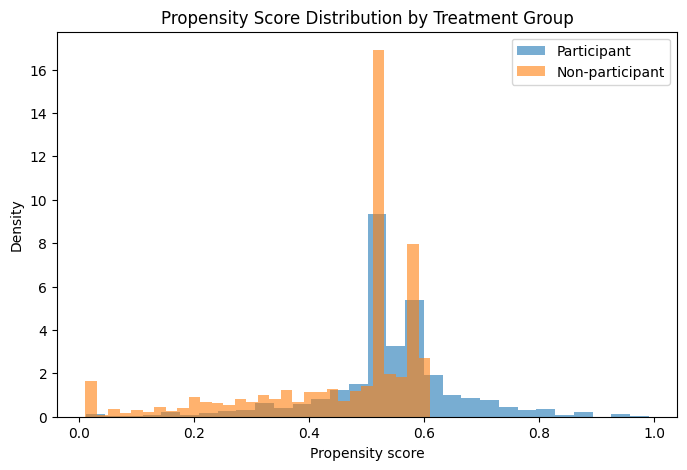

In [83]:
# --------------------------------------------------
# Plot propensity score distributions
# --------------------------------------------------

import matplotlib.pyplot as plt

treated_scores = ps_df.loc[ps_df["treatment"] == 1, "propensity_score_diagnostic"]
control_scores = ps_df.loc[ps_df["treatment"] == 0, "propensity_score_diagnostic"]

plt.figure(figsize=(8, 5))
plt.hist(treated_scores, bins=30, alpha=0.6, label="Participant", density=True)
plt.hist(control_scores, bins=30, alpha=0.6, label="Non-participant", density=True)
plt.xlabel("Propensity score")
plt.ylabel("Density")
plt.title("Propensity Score Distribution by Treatment Group")
plt.legend()
plt.show()

# Matching

In [90]:
# --------------------------------------------------
# Outcome means by treatment and cohort
# --------------------------------------------------
import statsmodels.formula.api as smf
reg_df = matched_analysis_df.copy()

# make sure types are clean
reg_df["treatment"] = pd.to_numeric(reg_df["treatment"], errors="coerce")
reg_df["cohort_2022"] = pd.to_numeric(reg_df["cohort_2022"], errors="coerce")

outcome_vars = [
    "employment_outcome",
    "earnings_outcome",
    "offense_outcome",
    "recidivism_outcome"
]

for outcome in outcome_vars:
    print(f"\n===== {outcome} =====")
    print(
        reg_df.groupby(["cohort_2022", "treatment"])[outcome]
        .agg(["count", "mean", "std"])
    )


===== employment_outcome =====
                       count      mean       std
cohort_2022 treatment                           
0.0         0            725  0.415172  0.493092
            1            725  0.591724  0.491854
1.0         0            257  0.638132  0.481478
            1            257  0.824903  0.380792

===== earnings_outcome =====
                       count          mean           std
cohort_2022 treatment                                   
0.0         0            725  10687.265454  32129.720965
            1            725  10162.947940  16709.630849
1.0         0            257  21624.764589  40287.949737
            1            257  15347.127039  20111.166242

===== offense_outcome =====
                       count      mean       std
cohort_2022 treatment                           
0.0         0            725  0.275862  0.447256
            1            725  0.140690  0.347941
1.0         0            257  0.128405  0.335193
            1            257

In [91]:
# --------------------------------------------------
# Main regressions: treatment * cohort_2022
# --------------------------------------------------

# 1. Employment outcome
model_emp = smf.ols(
    "employment_outcome ~ treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["pair_id"]})

print("\n===== Employment Outcome =====")
print(model_emp.summary())

# 2. Earnings outcome
model_earn = smf.ols(
    "earnings_outcome ~ treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["pair_id"]})

print("\n===== Earnings Outcome =====")
print(model_earn.summary())

# 3. Offense outcome
model_off = smf.ols(
    "offense_outcome ~ treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["pair_id"]})

print("\n===== Offense Outcome =====")
print(model_off.summary())

# 4. Recidivism outcome
model_recid = smf.ols(
    "recidivism_outcome ~ treatment * cohort_2022",
    data=reg_df
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["pair_id"]})

print("\n===== Recidivism Outcome =====")
print(model_recid.summary())


===== Employment Outcome =====
                            OLS Regression Results                            
Dep. Variable:     employment_outcome   R-squared:                       0.074
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     70.91
Date:                Fri, 10 Apr 2026   Prob (F-statistic):           1.65e-41
Time:                        12:36:25   Log-Likelihood:                -1334.7
No. Observations:                1964   AIC:                             2677.
Df Residuals:                    1960   BIC:                             2700.
Df Model:                           3                                         
Covariance Type:              cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

In [93]:
reg_df_log_earning = matched_analysis_df.copy()
reg_df_log_earning["log_earnings_outcome"] = np.log1p(reg_df["earnings_outcome"])

model_log_earn = smf.ols(
    "log_earnings_outcome ~ treatment * cohort_2022",
    data=reg_df_log_earning
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["pair_id"]})

print(model_log_earn.summary())

                             OLS Regression Results                             
Dep. Variable:     log_earnings_outcome   R-squared:                       0.071
Model:                              OLS   Adj. R-squared:                  0.069
Method:                   Least Squares   F-statistic:                     63.60
Date:                  Fri, 10 Apr 2026   Prob (F-statistic):           1.41e-37
Time:                          12:45:55   Log-Likelihood:                -5750.9
No. Observations:                  1964   AIC:                         1.151e+04
Df Residuals:                      1960   BIC:                         1.153e+04
Df Model:                             3                                         
Covariance Type:                cluster                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept 